# K-Means Clustering from Scratch
### Customer Segmentation & Sunset Image Compression

This notebook implements the **K-means clustering** algorithm from scratch (no `scikit-learn`) and applies it to two different problems:

1. A 2D **customer segmentation** dataset (Annual Income vs. Spending Score) — to build intuition for how K-means works.
2. A synthetically generated **sunset landscape image** — to see K-means used for **image color compression**.

Everything in this notebook is **self-contained**: the datasets and the image are generated with code (no external files needed), so you can run every cell top to bottom and push this straight to GitHub.

## Outline
- [1 - Implementing K-means](#1)
  - [1.1 Finding the closest centroids](#1.1)
  - [1.2 Computing centroid means](#1.2)
- [2 - K-means on a customer segmentation dataset](#2)
- [3 - Random initialization](#3)
- [4 - Image compression with K-means](#4)
- [5 - Bonus: Choosing K with the Elbow Method](#5)


First, let's import the libraries we need. Everything here is standard: `numpy` for the math, `matplotlib` for plotting. No helper/utility files are required — every function used in this notebook is defined here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)


<a name="1"></a>
## 1 - Implementing K-means

K-means is a method to automatically group similar data points together into clusters.

* You are given a training set $\{x^{(1)}, ..., x^{(m)}\}$ and want to group it into $K$ cohesive clusters.
* K-means is an **iterative** procedure:
    * Start by guessing the initial centroids.
    * Repeat:
        1. **Assign** every point to its closest centroid.
        2. **Recompute** each centroid as the mean of the points assigned to it.

```python
# Initialize centroids
centroids = kMeans_init_centroids(X, K)

for iter in range(iterations):
    # Cluster assignment step
    idx = find_closest_centroids(X, centroids)

    # Move centroid step
    centroids = compute_centroids(X, idx, K)
```

We'll implement the two core steps ourselves: `find_closest_centroids` and `compute_centroids`.


<a name="1.1"></a>
### 1.1 Finding the closest centroids

In the "cluster assignment" step, every training example $x^{(i)}$ is assigned to its closest centroid:

$$c^{(i)} := \arg\min_j \; ||x^{(i)} - \mu_j||^2$$

where
* $c^{(i)}$ is the index of the centroid closest to $x^{(i)}$ (stored in `idx[i]`)
* $\mu_j$ is the position of the $j$-th centroid


In [2]:
def find_closest_centroids(X, centroids):
    '''
    Computes the centroid membership for every example.

    Args:
        X (ndarray):         (m, n) Input values
        centroids (ndarray): (K, n) centroids

    Returns:
        idx (ndarray): (m,) index of the closest centroid for each example
    '''
    K = centroids.shape[0]
    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(X.shape[0]):
        distances = []
        for j in range(K):
            norm_ij = np.linalg.norm(X[i] - centroids[j])
            distances.append(norm_ij)
        idx[i] = np.argmin(distances)

    return idx


Let's build a brand-new dataset to test this on: a synthetic **customer segmentation** dataset with two features — `Annual Income (k$)` and `Spending Score (1-100)` — grouped into 3 natural segments:

* **Budget-conscious** shoppers (low income, low spending)
* **High-income savers** (high income, low spending)
* **Big spenders** (mid income, high spending)

This mirrors a classic real-world use case for K-means (mall / e-commerce customer segmentation), but every point is generated in code so the notebook needs no external CSV.

In [3]:
def generate_customer_data(seed=1):
    '''
    Generates a synthetic 2D customer segmentation dataset:
    columns = [Annual Income (k$), Spending Score (1-100)]
    '''
    rng = np.random.default_rng(seed)

    budget_conscious    = rng.normal(loc=[25, 22], scale=[6, 8],  size=(60, 2))
    high_income_savers  = rng.normal(loc=[85, 20], scale=[7, 7],  size=(55, 2))
    big_spenders        = rng.normal(loc=[58, 80], scale=[8, 7],  size=(65, 2))

    X = np.vstack([budget_conscious, high_income_savers, big_spenders])
    X = np.clip(X, 1, 100)  # keep values in a sensible range
    rng.shuffle(X)
    return X

X = generate_customer_data()


Let's inspect the first few rows and the shape of `X`.

In [4]:
print("First five examples in X (Income, Spending Score):\n", X[:5])
print("\nShape of X is:", X.shape)


First five examples in X (Income, Spending Score):
 [[15.2149 12.4387]
 [55.1616 82.274 ]
 [63.0993 79.7859]
 [52.9927 82.3323]
 [46.701  85.3923]]

Shape of X is: (180, 2)


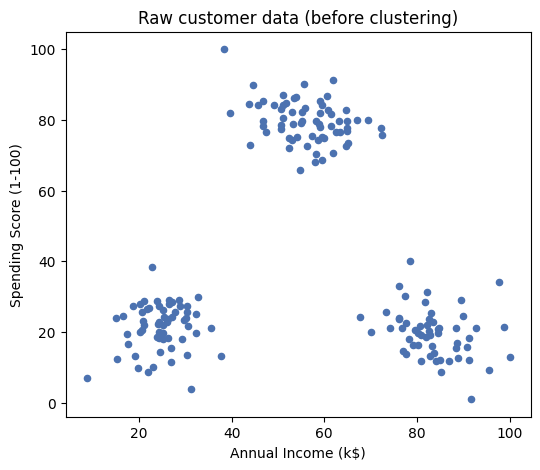

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, color="#4C72B0")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Raw customer data (before clustering)")
plt.show()


In [6]:
# Pick 3 initial centroids (deliberately not exactly on the clusters,
# so we can watch K-means move them into place)
initial_centroids = np.array([[30, 30], [70, 20], [50, 70]])

idx = find_closest_centroids(X, initial_centroids)

print("First three elements in idx are:", idx[:3])


First three elements in idx are: [0 2 2]


<a name="1.2"></a>
### 1.2 Computing centroid means

Given the cluster assignments, the second step recomputes each centroid as the **mean** of the points assigned to it:

$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$

where $C_k$ is the set of examples assigned to centroid $k$.


In [7]:
def compute_centroids(X, idx, K):
    '''
    Returns new centroids by computing the mean of the points
    assigned to each centroid.

    Args:
        X (ndarray):   (m, n) data points
        idx (ndarray): (m,) index of the closest centroid for each example
        K (int):       number of centroids

    Returns:
        centroids (ndarray): (K, n) new centroids
    '''
    m, n = X.shape
    centroids = np.zeros((K, n))

    for k in range(K):
        points = X[idx == k]
        centroids[k] = np.mean(points, axis=0)

    return centroids


In [8]:
K = 3
centroids = compute_centroids(X, idx, K)
print("New centroids computed from the initial assignment:\n", centroids)


New centroids computed from the initial assignment:
 [[24.7878 21.456 ]
 [83.4514 19.7489]
 [56.2575 79.592 ]]


<a name="2"></a>
## 2 - K-means on the customer segmentation dataset

Now let's put the two pieces together and run full K-means, visualizing how the centroids move on every iteration.

In [9]:
def compute_cost(X, idx, centroids):
    '''
    Computes the K-means distortion cost (average squared distance
    from each point to its assigned centroid). Lower is better.
    '''
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        cost += np.sum((X[i] - centroids[idx[i]]) ** 2)
    return cost / m


def plot_kMeans_progress(X, centroids, previous_centroids, idx, K, iteration, ax):
    '''Plots one iteration of K-means: colored clusters, centroids (X marks),
    and a dashed line showing how each centroid moved since the last step.'''
    colors = plt.cm.tab10(np.arange(K) % 10)

    for k in range(K):
        pts = X[idx == k]
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[k], s=18, alpha=0.55)

    ax.scatter(centroids[:, 0], centroids[:, 1], marker="x", c="black",
               s=140, linewidths=3, zorder=5)

    for k in range(K):
        ax.plot([previous_centroids[k, 0], centroids[k, 0]],
                [previous_centroids[k, 1], centroids[k, 1]],
                "k--", linewidth=1)

    ax.set_title(f"K-Means progress (through iteration {iteration})")


def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    '''Runs the K-Means algorithm on data matrix X.'''
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids.copy()
    previous_centroids = centroids.copy()
    idx = np.zeros(m, dtype=int)

    if plot_progress:
        fig, ax = plt.subplots(figsize=(7, 6))

    for i in range(max_iters):
        idx = find_closest_centroids(X, centroids)

        if plot_progress:
            plot_kMeans_progress(X, centroids, previous_centroids, idx, K, i, ax)
            previous_centroids = centroids.copy()

        centroids = compute_centroids(X, idx, K)

    if plot_progress:
        ax.set_xlabel("Annual Income (k$)")
        ax.set_ylabel("Spending Score (1-100)")
        plt.show()

    return centroids, idx


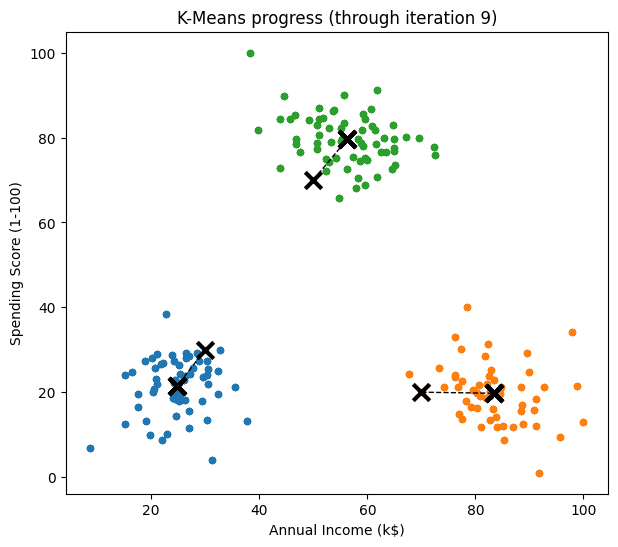


Final centroids (Income, Spending Score):
 [[24.7878 21.456 ]
 [83.4514 19.7489]
 [56.2575 79.592 ]]
Final distortion cost: 83.942


In [10]:
# Set initial centroids and run K-Means
initial_centroids = np.array([[30, 30], [70, 20], [50, 70]])
max_iters = 10

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

print("\nFinal centroids (Income, Spending Score):\n", centroids)
print("Final distortion cost:", round(compute_cost(X, idx, centroids), 3))


<a name="3"></a>
## 3 - Random initialization

In practice, a good strategy is to initialize centroids by picking $K$ random examples from the training set itself (rather than guessing values by hand).

* `kMeans_init_centroids` randomly shuffles the example indices with `np.random.permutation` and takes the first $K$ as the initial centroids.
* Because K-means can converge to different (and sometimes worse) local optima depending on the initial centroids, a common trick is to **run K-means several times with different random initializations** and keep the result with the lowest cost (distortion).


In [11]:
def kMeans_init_centroids(X, K, seed=None):
    '''
    Randomly picks K examples from X to use as initial centroids.

    Args:
        X (ndarray): data points
        K (int):     number of centroids/clusters

    Returns:
        centroids (ndarray): (K, n) initialized centroids
    '''
    rng = np.random.default_rng(seed)
    randidx = rng.permutation(X.shape[0])
    centroids = X[randidx[:K]]
    return centroids


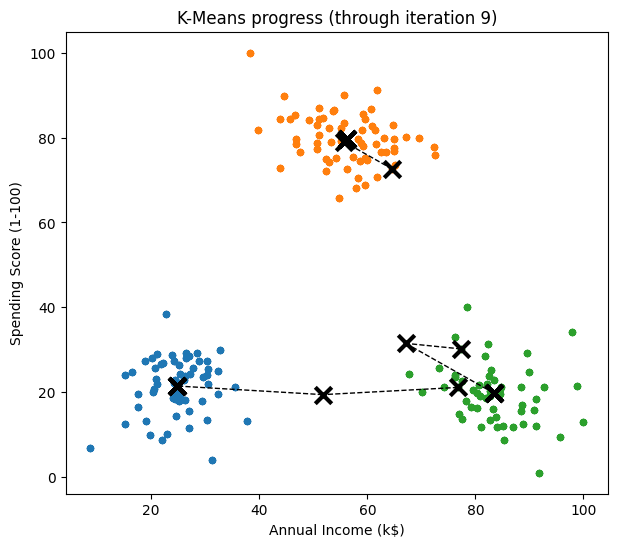

In [12]:
# Run K-Means once with random initial centroids
K = 3
max_iters = 10

initial_centroids = kMeans_init_centroids(X, K, seed=42)
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)


### Running multiple random initializations and keeping the best

A single random start can land in a mediocre local optimum. Let's run K-means several times with different random starts and keep the run with the **lowest distortion cost**.

In [13]:
def run_kMeans_with_random_restarts(X, K, n_init=10, max_iters=10, seed=0):
    '''Runs K-means n_init times with different random initial centroids
    and returns the best result (lowest distortion cost).'''
    rng = np.random.default_rng(seed)
    best_cost = np.inf
    best_centroids, best_idx = None, None

    for run in range(n_init):
        init_centroids = kMeans_init_centroids(X, K, seed=int(rng.integers(1e6)))
        centroids, idx = run_kMeans(X, init_centroids, max_iters, plot_progress=False)
        cost = compute_cost(X, idx, centroids)

        if cost < best_cost:
            best_cost, best_centroids, best_idx = cost, centroids, idx

    return best_centroids, best_idx, best_cost


best_centroids, best_idx, best_cost = run_kMeans_with_random_restarts(X, K=3, n_init=10)
print("Best distortion cost across 10 random restarts:", round(best_cost, 3))
print("Best centroids found:\n", best_centroids)


Best distortion cost across 10 random restarts: 83.942
Best centroids found:
 [[56.2575 79.592 ]
 [24.7878 21.456 ]
 [83.4514 19.7489]]


<a name="4"></a>
## 4 - Image compression with K-means

Now for the second (and more visual) application: **image color compression**.

* A 24-bit color image stores each pixel as three 8-bit values (R, G, B) — so it can contain thousands of unique colors.
* K-means can find the $K$ colors that best represent the image, so instead of storing 24 bits per pixel, we only need to store the index of one of $K$ colors per pixel (plus a small color lookup table).

Instead of relying on an external image file, we'll **generate a synthetic sunset landscape image directly in code**. That keeps the whole notebook self-contained and runnable anywhere — no missing file errors when you upload this to GitHub.

<a name="4.1"></a>
### 4.1 Generate the dataset (a synthetic sunset image)

In [14]:
def generate_sunset_image(width=160, height=120, seed=7):
    '''Generates a synthetic sunset-over-mountains image as an (H, W, 3)
    uint8 array, purely with numpy (no external files needed).'''
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:height, 0:width]
    t = yy / (height - 1)  # 0 at top, 1 at bottom

    top    = np.array([20, 24, 82])    # deep night blue
    middle = np.array([255, 111, 97])  # coral sunset
    bottom = np.array([255, 200, 87])  # golden horizon

    img = np.zeros((height, width, 3), dtype=np.float64)

    upper_mask = t < 0.5
    lower_mask = ~upper_mask
    t_upper = np.clip(t / 0.5, 0, 1)[..., None]
    t_lower = np.clip((t - 0.5) / 0.5, 0, 1)[..., None]

    img[upper_mask] = (top * (1 - t_upper) + middle * t_upper)[upper_mask]
    img[lower_mask] = (middle * (1 - t_lower) + bottom * t_lower)[lower_mask]

    # Sun
    cx, cy, r = width * 0.72, height * 0.32, width * 0.09
    sun_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    img[sun_mask] = [255, 247, 214]

    # Back mountain range (dark purple)
    ridge1 = height * 0.72 - (width / 2 - np.abs(xx - width * 0.38)) * 0.32
    img[yy > ridge1] = [46, 33, 66]

    # Front mountain range (darkest, in front)
    ridge2 = height * 0.85 - (width / 2 - np.abs(xx - width * 0.66)) * 0.26
    img[yy > ridge2] = [27, 18, 43]

    # Subtle texture/noise so the image has thousands of distinct colors,
    # just like a real photo
    noise = rng.normal(0, 3, img.shape)
    img = np.clip(img + noise, 0, 255).astype(np.uint8)
    return img


original_img = generate_sunset_image()


**Visualize the image**

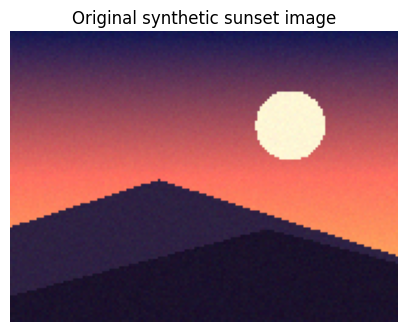

In [15]:
plt.figure(figsize=(5, 4))
plt.imshow(original_img)
plt.axis("off")
plt.title("Original synthetic sunset image")
plt.show()


**Check the shape**

In [16]:
print("Shape of original_img is:", original_img.shape)

unique_colors = np.unique(original_img.reshape(-1, 3), axis=0)
print("Number of unique colors in the original image:", len(unique_colors))


Shape of original_img is: (120, 160, 3)
Number of unique colors in the original image: 12496


As before, `original_img` is a 3D array: the first two indices identify a pixel position, and the third represents R, G, or B.

To run K-means, we reshape it into an $m \times 3$ matrix where every row is one pixel's RGB color.

In [17]:
# Reshape the image into an (m, 3) matrix of pixel colors
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))
X_img = X_img.astype(np.float64)

print("Shape of X_img:", X_img.shape)


Shape of X_img: (19200, 3)


<a name="4.2"></a>
### 4.2 K-Means on image pixels

Now run K-means on the pixel colors to find the $K=16$ colors that best represent the image.

In [18]:
K = 16
max_iters = 10

initial_centroids = kMeans_init_centroids(X_img, K, seed=3)
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters, plot_progress=False)

print("Shape of idx:", idx.shape)
print("Closest centroid for the first five pixels:", idx[:5])


Shape of idx: (19200,)
Closest centroid for the first five pixels: [15 15 15 15 15]


Let's plot every pixel's color in 3D RGB space, with the 16 chosen centroids marked in black. You'll see thousands of small dots (the original colors) clustering around the 16 representative colors K-means found.

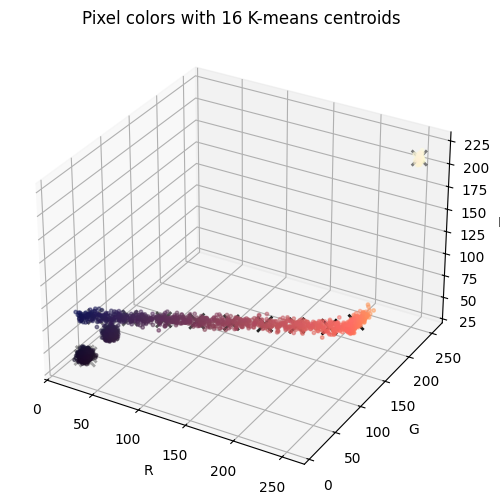

In [19]:
def plot_pixel_colors_3d(X_img, centroids, idx, K, sample_size=2000, seed=0):
    '''Scatter-plots pixel colors in RGB space with the K centroids marked.'''
    rng = np.random.default_rng(seed)
    m = X_img.shape[0]
    sample_idx = rng.choice(m, size=min(sample_size, m), replace=False)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    colors_normalized = X_img[sample_idx] / 255.0
    ax.scatter(X_img[sample_idx, 0], X_img[sample_idx, 1], X_img[sample_idx, 2],
               c=colors_normalized, s=6, alpha=0.5)

    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
               c="black", marker="x", s=120, linewidths=2)

    ax.set_xlabel("R")
    ax.set_ylabel("G")
    ax.set_zlabel("B")
    ax.set_title(f"Pixel colors with {K} K-means centroids")
    plt.show()


plot_pixel_colors_3d(X_img, centroids, idx, K)


Let's also look at the 16 colors themselves as swatches — these are the only colors that will appear in the compressed image.

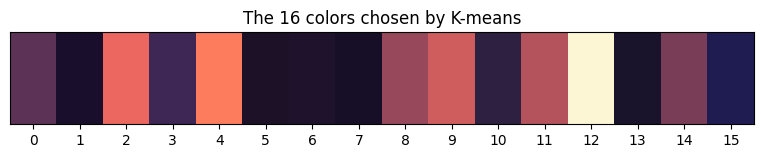

In [20]:
def show_centroid_colors(centroids):
    '''Displays each centroid as a labeled color swatch.'''
    K = centroids.shape[0]
    palette = np.clip(centroids, 0, 255).astype(np.uint8).reshape(1, K, 3)

    plt.figure(figsize=(K * 0.6, 1.2))
    plt.imshow(palette, aspect="auto")
    plt.xticks(range(K), range(K))
    plt.yticks([])
    plt.title(f"The {K} colors chosen by K-means")
    plt.show()


show_centroid_colors(centroids)


<a name="4.3"></a>
### 4.3 Compress the image

Finally, we replace every pixel with the color of its closest centroid, using the same `find_closest_centroids` function from Section 1.

* The original image needs $8 \times 3 = 24$ bits per pixel.
* The compressed version needs a 16-color lookup table ($16 \times 24$ bits) plus only 4 bits per pixel (since $2^4 = 16$).

In [21]:
# Find the closest centroid for every pixel, then replace it with that centroid's color
idx = find_closest_centroids(X_img, centroids)
X_recovered = centroids[idx, :]

# Reshape back into the original image dimensions
X_recovered = np.reshape(X_recovered, original_img.shape).astype(np.uint8)


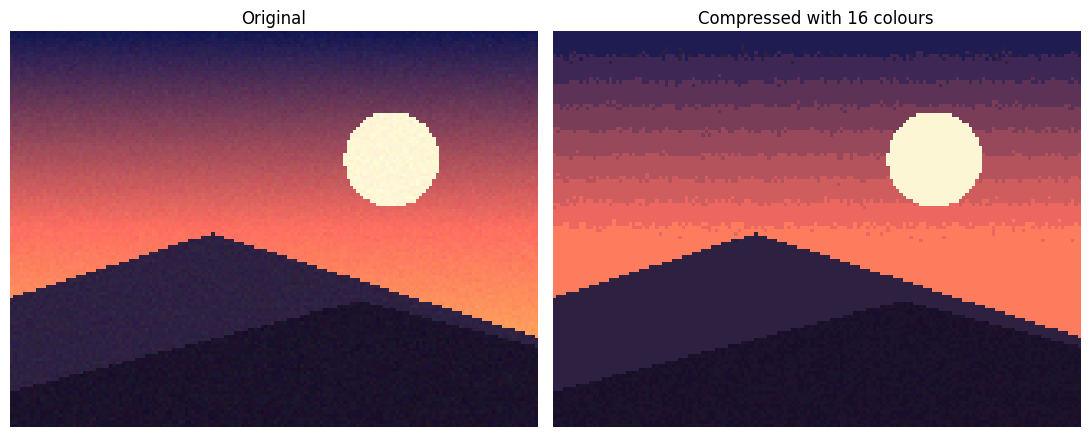

Original size:   460,800 bits
Compressed size: 77,184 bits
Compression factor: 5.97x


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 6))

ax[0].imshow(original_img)
ax[0].set_title("Original")
ax[0].set_axis_off()

ax[1].imshow(X_recovered)
ax[1].set_title(f"Compressed with {K} colours")
ax[1].set_axis_off()

plt.tight_layout()
plt.show()

h, w, _ = original_img.shape
original_bits = h * w * 24
compressed_bits = K * 24 + h * w * 4
print(f"Original size:   {original_bits:,} bits")
print(f"Compressed size: {compressed_bits:,} bits")
print(f"Compression factor: {original_bits / compressed_bits:.2f}x")


<a name="5"></a>
## 5 - Bonus: Choosing K with the Elbow Method

How do we pick a good value of $K$ in the first place? One common heuristic is the **elbow method**: run K-means for a range of $K$ values, plot the resulting distortion cost, and look for the point where adding more clusters stops giving a big improvement (the "elbow").

Let's apply this to the customer segmentation dataset from Section 2.

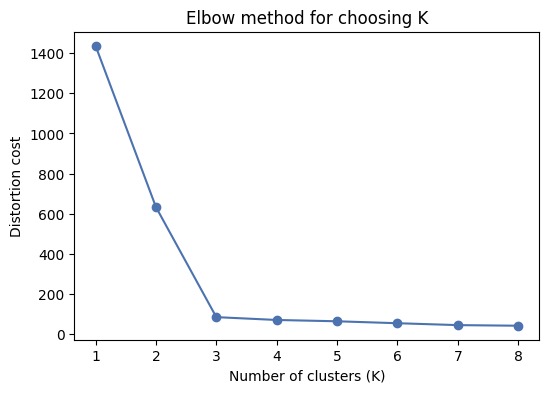

In [23]:
K_values = range(1, 9)
costs = []

for k in K_values:
    centroids_k, idx_k, cost_k = run_kMeans_with_random_restarts(X, K=k, n_init=5, max_iters=10)
    costs.append(cost_k)

plt.figure(figsize=(6, 4))
plt.plot(list(K_values), costs, "o-", color="#4C72B0")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Distortion cost")
plt.title("Elbow method for choosing K")
plt.xticks(list(K_values))
plt.show()


For this dataset, the cost drops sharply up to around $K=3$ and then flattens out — which matches how we actually generated the data (3 customer segments)!

## Summary

In this notebook you implemented K-means clustering completely from scratch:
- `find_closest_centroids` — the cluster assignment step
- `compute_centroids` — the centroid update step
- `run_kMeans` — the full iterative algorithm, with progress visualization
- `kMeans_init_centroids` — random initialization, plus running multiple restarts to avoid poor local optima
- Applied K-means to **customer segmentation** (2D data) and **image color compression** (a synthetic sunset image)
- Used the **elbow method** to pick a good value of $K$

Everything here was generated in-notebook, so it's ready to run end-to-end and upload as-is.